# Análise Exploratória de Dados: World Happiness Report
Este notebook faz parte de um estudo prático de EDA, replicando técnicas de análise 
em um dataset real extraído do Kaggle. O objetivo é entender quais fatores 
(PIB, suporte social, liberdade) mais influenciam na percepção de felicidade global.

## Carregamento dos Dados
Nesta etapa, é feita a importação das bibliotecas necessárias e carregamos o dataset de 2019. 
Optou-se por utilizar o nome do país como índice para facilitar a análise exploratória.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/2019.csv', index_col='Country or region')

df.head()


,Overall rank,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
Country or region,,,,,,,,
Finland,1,7.769,1.340,1.587,0.986,0.596,0.153,0.393
Denmark,2,7.600,1.383,1.573,0.996,0.592,0.252,0.410
Norway,3,7.554,1.488,1.582,1.028,0.603,0.271,0.341
Iceland,4,7.494,1.380,1.624,1.026,0.591,0.354,0.118
Netherlands,5,7.488,1.396,1.522,0.999,0.557,0.322,0.298


In [2]:
df.info()

<class 'pandas.DataFrame'>
Index: 156 entries, Finland to South Sudan
Data columns (total 8 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Overall rank                  156 non-null    int64  
 1   Score                         156 non-null    float64
 2   GDP per capita                156 non-null    float64
 3   Social support                156 non-null    float64
 4   Healthy life expectancy       156 non-null    float64
 5   Freedom to make life choices  156 non-null    float64
 6   Generosity                    156 non-null    float64
 7   Perceptions of corruption     156 non-null    float64
dtypes: float64(7), int64(1)
memory usage: 11.0+ KB


### Verificação de Dados Ausentes

In [3]:
df.isna().sum()

Overall rank                    0
Score                           0
GDP per capita                  0
Social support                  0
Healthy life expectancy         0
Freedom to make life choices    0
Generosity                      0
Perceptions of corruption       0
dtype: int64

### Conclusão da Validação de Dados
Após verificar a integridade do dataset, identificou-se que não há valores ausentes (NaN). 
Assim, pode-se avançar diretamente para a análise estatística.

### Seleção de Variáveis de Interesse
Para uma análise mais objetiva, optou-se focar apenas nos fatores que compõem o índice de felicidade. Assim, descartou-se o 'Overall rank', pois ele é apenas uma classificação derivada do 'Score'.

In [4]:
colunas_analise = [
    'Score', 'GDP per capita', 'Social support', 
    'Healthy life expectancy', 'Freedom to make life choices', 
    'Generosity', 'Perceptions of corruption'
]

df_clean = df[colunas_analise]

df_clean.head()

,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
Country or region,,,,,,,
Finland,7.769,1.340,1.587,0.986,0.596,0.153,0.393
Denmark,7.600,1.383,1.573,0.996,0.592,0.252,0.410
Norway,7.554,1.488,1.582,1.028,0.603,0.271,0.341
Iceland,7.494,1.380,1.624,1.026,0.591,0.354,0.118
Netherlands,7.488,1.396,1.522,0.999,0.557,0.322,0.298


### Análise Estatística Descritiva
Com o dataset filtrado, utilizou-se o método `describe()` para observar a distribuição dos dados. Isso permite identificar a média global de felicidade, 
o desvio padrão entre os países e os valores extremos (mínimos e máximos).

In [5]:
df_clean.describe().round(2)

,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
count,156.00,156.00,156.00,156.00,156.00,156.00,156.00
mean,5.41,0.91,1.21,0.73,0.39,0.18,0.11
std,1.11,0.40,0.30,0.24,0.14,0.10,0.09
min,2.85,0.00,0.00,0.00,0.00,0.00,0.00
25%,4.54,0.60,1.06,0.55,0.31,0.11,0.05
50%,5.38,0.96,1.27,0.79,0.42,0.18,0.09
75%,6.18,1.23,1.45,0.88,0.51,0.25,0.14
max,7.77,1.68,1.62,1.14,0.63,0.57,0.45


### Insights Iniciais (Distribuição Global)
Ao analisar as estatísticas descritivas, observa-se que:
* **Felicidade:** A média mundial está em torno de 5.4, com uma variação considerável entre o mínimo e o máximo.
* **Economia:** O PIB per capita é o fator com maior teto de pontuação, sugerindo ser um forte candidato a influenciar o Score final.
* **Corrupção:** É o fator que menos contribui para a nota de felicidade na maioria dos países. A média baixa indica que a confiança nas instituições (governo e empresas) ainda é um desafio global e impacta pouco positivamente no bem-estar geral, quando comparada a fatores como Economia e Suporte Social.

### Tratamento de Dados Categóricos
Diferente das variáveis numéricas, os dados categóricos permitem agrupar a análise por grupos (neste caso, por regiões do mundo). Como o dataset de 2019 não inclui a coluna de região, importou-se essa informação do dataset de 2015 para enriquecer a nossa análise exploratória.

In [6]:
# Lendo apenas as colunas necessárias do arquivo de 2015
df_regioes = pd.read_csv('../data/2015.csv', usecols=['Country', 'Region'], index_col='Country')

# Adicionando a coluna 'Region' ao  dataframe de 2019 (df_clean)
df_final = df_clean.join(df_regioes)

df_final.head()

,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption,Region
Country or region,,,,,,,,
Finland,7.769,1.340,1.587,0.986,0.596,0.153,0.393,Western Europe
Denmark,7.600,1.383,1.573,0.996,0.592,0.252,0.410,Western Europe
Norway,7.554,1.488,1.582,1.028,0.603,0.271,0.341,Western Europe
Iceland,7.494,1.380,1.624,1.026,0.591,0.354,0.118,Western Europe
Netherlands,7.488,1.396,1.522,0.999,0.557,0.322,0.298,Western Europe


In [7]:
df_final.isna().sum()

Score                           0
GDP per capita                  0
Social support                  0
Healthy life expectancy         0
Freedom to make life choices    0
Generosity                      0
Perceptions of corruption       0
Region                          7
dtype: int64

In [8]:
# Filtrando apenas as linhas onde a região está nula
df_final[df_final['Region'].isna()]

,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption,Region
Country or region,,,,,,,,
Trinidad & Tobago,6.192,1.231,1.477,0.713,0.489,0.185,0.016,NaN
Northern Cyprus,5.718,1.263,1.252,1.042,0.417,0.191,0.162,NaN
North Macedonia,5.274,0.983,1.294,0.838,0.345,0.185,0.034,NaN
Somalia,4.668,0.000,0.698,0.268,0.559,0.243,0.270,NaN
Namibia,4.639,0.879,1.313,0.477,0.401,0.070,0.056,NaN
Gambia,4.516,0.308,0.939,0.428,0.382,0.269,0.167,NaN
South Sudan,2.853,0.306,0.575,0.295,0.010,0.202,0.091,NaN


### Tratamento de Dados Ausentes (Pós-Junção)
Ao cruzar os dados de 2019 com as regiões de 2015, identificou-se 7 países sem correspondência de região. Em vez de descartar esses dados, optou-se pela 
imputação manual para preservar a integridade da amostra global.

In [9]:
# Preenchendo as regiões com base na localização geográfica
df_final.loc['Trinidad & Tobago', 'Region'] = 'Latin America and Caribbean'
df_final.loc['Northern Cyprus', 'Region'] = 'Western Europe'
df_final.loc['North Macedonia', 'Region'] = 'Central and Eastern Europe'
df_final.loc['Somalia', 'Region'] = 'Sub-Saharan Africa'
df_final.loc['Namibia', 'Region'] = 'Sub-Saharan Africa'
df_final.loc['Gambia', 'Region'] = 'Sub-Saharan Africa'
df_final.loc['South Sudan', 'Region'] = 'Sub-Saharan Africa'

print(f"Total de nulos em Region: {df_final['Region'].isna().sum()}")

Total de nulos em Region: 0


In [10]:
df_final.groupby('Region')['Score'].mean().sort_values(ascending=False)

Region
Australia and New Zealand          7.267500
North America                      7.085000
Western Europe                     6.842190
Latin America and Caribbean        5.954429
Eastern Asia                       5.688833
Central and Eastern Europe         5.561517
Southeastern Asia                  5.273667
Middle East and Northern Africa    5.237000
Southern Asia                      4.526857
Sub-Saharan Africa                 4.300050
Name: Score, dtype: float64

### Padronização de Tipos Categóricos
Seguindo as boas práticas de manipulação de dados, converteu-se a coluna 'Region' do tipo genérico (object) para o tipo específico (string), visando garantir maior consistência para as operações de texto que se realizará adiante.

In [11]:
df_final['Region'] = df_final['Region'].astype('string')

df_final['Region'].dtype

<StringDtype(storage='python', na_value=<NA>)>

In [12]:
df_final['Region'].unique()

<StringArray>
[                 'Western Europe',       'Australia and New Zealand',
                   'North America',     'Latin America and Caribbean',
 'Middle East and Northern Africa',      'Central and Eastern Europe',
                    'Eastern Asia',               'Southeastern Asia',
              'Sub-Saharan Africa',                   'Southern Asia']
Length: 10, dtype: string

### Distribuição Geográfica dos Países
Utilizou-se o método `value_counts()` para entender quantos países de cada região compõem o relatório de 2019. Isso ajudará a identificar se a pesquisa 
possui uma cobertura equilibrada globalmente.

In [13]:
distribuicao_percentual = df_final['Region'].value_counts(normalize=True) * 100
distribuicao_percentual.round(2).astype(str) + '%'

Region
Sub-Saharan Africa                 25.64%
Central and Eastern Europe         18.59%
Western Europe                     13.46%
Latin America and Caribbean        13.46%
Middle East and Northern Africa    12.18%
Southeastern Asia                   5.77%
Southern Asia                       4.49%
Eastern Asia                        3.85%
Australia and New Zealand           1.28%
North America                       1.28%
Name: proportion, dtype: str

In [14]:
df_final['Status_Felicidade'] = df_final['Score'].apply(lambda x: 'Feliz' if x > 6 else 'Menos Feliz')

# Cruzando Região com Status de Felicidade
df_final[['Region', 'Status_Felicidade']].value_counts().sort_index()

Region                           Status_Felicidade
Australia and New Zealand        Feliz                 2
Central and Eastern Europe       Feliz                 8
                                 Menos Feliz          21
Eastern Asia                     Feliz                 1
                                 Menos Feliz           5
Latin America and Caribbean      Feliz                13
                                 Menos Feliz           8
Middle East and Northern Africa  Feliz                 6
                                 Menos Feliz          13
North America                    Feliz                 2
Southeastern Asia                Feliz                 2
                                 Menos Feliz           7
Southern Asia                    Menos Feliz           7
Sub-Saharan Africa               Menos Feliz          40
Western Europe                   Feliz                18
                                 Menos Feliz           3
Name: count, dtype: int64

In [15]:
# Verificando apenas países da América Latina
df_final[df_final['Region'] == 'Latin America and Caribbean']

,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption,Region,Status_Felicidade
Country or region,,,,,,,,,
Costa Rica,7.167,1.034,1.441,0.963,0.558,0.144,0.093,Latin America and Caribbean,Feliz
Mexico,6.595,1.070,1.323,0.861,0.433,0.074,0.073,Latin America and Caribbean,Feliz
Chile,6.444,1.159,1.369,0.920,0.357,0.187,0.056,Latin America and Caribbean,Feliz
Guatemala,6.436,0.800,1.269,0.746,0.535,0.175,0.078,Latin America and Caribbean,Feliz
Panama,6.321,1.149,1.442,0.910,0.516,0.109,0.054,Latin America and Caribbean,Feliz
Brazil,6.300,1.004,1.439,0.802,0.390,0.099,0.086,Latin America and Caribbean,Feliz
Uruguay,6.293,1.124,1.465,0.891,0.523,0.127,0.150,Latin America and Caribbean,Feliz
El Salvador,6.253,0.794,1.242,0.789,0.430,0.093,0.074,Latin America and Caribbean,Feliz
Trinidad & Tobago,6.192,1.231,1.477,0.713,0.489,0.185,0.016,Latin America and Caribbean,Feliz


### Consolidação de Indicadores por Região
Para finalizar a etapa de manipulação de dados, gerou-se um resumo estatístico agrupado. Este quadro permite comparar não apenas o Score, mas como o PIB e o Suporte Social variam entre os blocos geográficos, servindo de base para as visualizações de Boxplot na próxima etapa.

In [16]:
# Criando um resumo com a média de felicidade e dos dois principais fatores
resumo_regional = df_final.groupby('Region')[['Score', 'GDP per capita', 'Social support']].mean()

# Ordenando pela maior felicidade média
resumo_regional.sort_values(by='Score', ascending=False).round(2)

,Score,GDP per capita,Social support
Region,,,
Australia and New Zealand,7.27,1.34,1.55
North America,7.08,1.40,1.48
Western Europe,6.84,1.36,1.47
Latin America and Caribbean,5.95,0.92,1.34
Eastern Asia,5.69,1.24,1.33
Central and Eastern Europe,5.56,1.02,1.34
Southeastern Asia,5.27,0.93,1.25
Middle East and Northern Africa,5.24,1.06,1.15
Southern Asia,4.53,0.65,0.99


As colunas de fatores (PIB, Saúde, etc.) não somam 100% do Score. Elas representam o quanto cada um desses pilares contribui para explicar a felicidade, mas ainda existe uma parcela da nota (o resíduo) que vem de fatores não mensurados diretamente pelo relatório.

In [17]:
df_final.columns


Index(['Score', 'GDP per capita', 'Social support', 'Healthy life expectancy',
       'Freedom to make life choices', 'Generosity',
       'Perceptions of corruption', 'Region', 'Status_Felicidade'],
      dtype='str')

## Visualização com Boxplot
Iniciou-se a análise visual utilizando as bibliotecas `matplotlib` e `seaborn`. O Boxplot permite visualizar a distribuição dos dados de felicidade, 
identificando a mediana, os quartis e possíveis *outliers* (valores atípicos).

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set()
sns.set_context('talk')

df_clean['Score'].describe().round(2)

count    156.00
mean       5.41
std        1.11
min        2.85
25%        4.54
50%        5.38
75%        6.18
max        7.77
Name: Score, dtype: float64

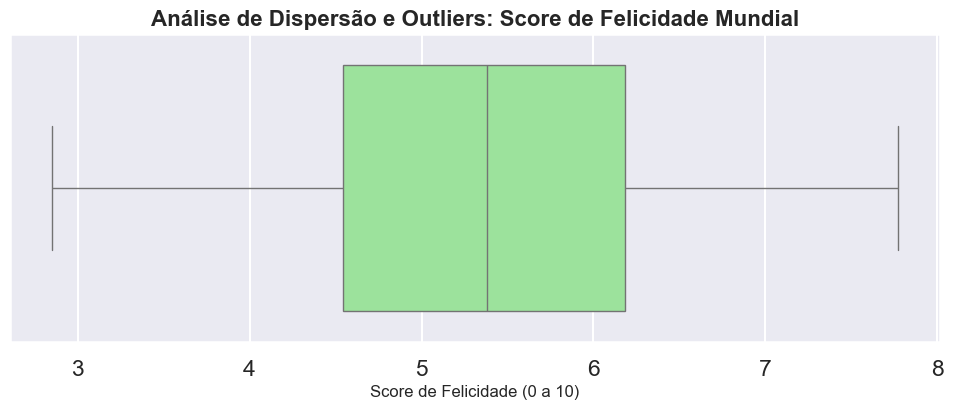

In [19]:
fig, ax = plt.subplots(figsize=(12, 4))
sns.boxplot(data=df_final, x="Score", color='lightgreen', ax=ax)
ax.set_title('Análise de Dispersão e Outliers: Score de Felicidade Mundial', fontsize=16, fontweight='bold')
ax.set_xlabel('Score de Felicidade (0 a 10)', fontsize=12)

plt.show()

**Curiosidade Estatística:** O valor de `whis` define o limite para detecção de outliers baseado na Amplitude Interquartílica ($IQR = Q3 - Q1$). Enquanto o padrão 1.5 de Tukey cobre ~99.3% de uma distribuição normal, o valor 3.0 (usado na aula, mas em outro dataset) foca em anomalias extremas. No nosso dataset, a ausência de pontos extremos mesmo com `whis=1.5` indica uma distribuição sem discrepâncias severas.

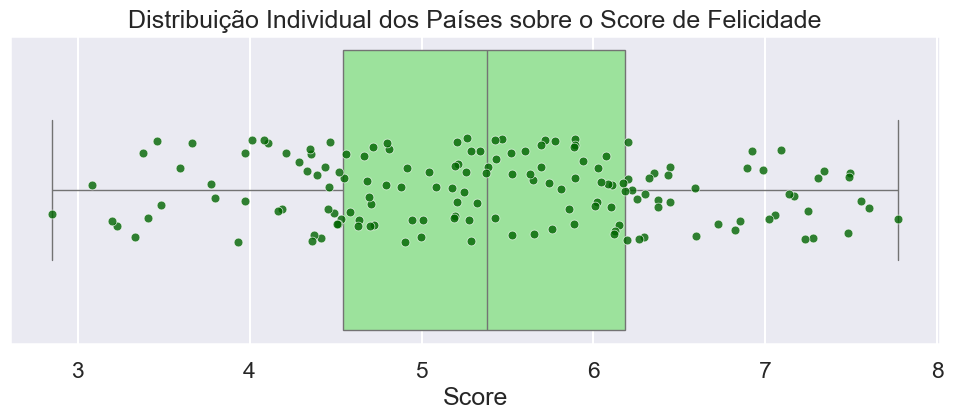

In [20]:
import numpy as np

# Criando o ruído apenas para o eixo Y (para espalhar os países verticalmente)
y_noise = np.random.uniform(-0.15, 0.15, len(df_final))

fig, ax = plt.subplots(figsize=(12, 4))

# Boxplot base
sns.boxplot(data=df_final, x='Score', ax=ax, color='lightgreen', showfliers=False, zorder=1 )

# Scatterplot com Jitter (usando o y_noise)
sns.scatterplot(x=df_final['Score'], y=y_noise, alpha=0.8, s=40, color='darkgreen', zorder=2)

ax.set_title('Distribuição Individual dos Países sobre o Score de Felicidade')
# Esconde o eixo Y já que o ruído é apenas estético
ax.get_yaxis().set_visible(False) 

plt.show()

Técnica de Jittering: Adicionamos um ruído aleatório via numpy no eixo Y para dispersar os pontos do scatterplot. Isso evita a sobreposição (overplotting) e permite visualizar a densidade real de países em cada faixa de Score.

In [21]:
# Identificando os extremos 
top_5_felizes = df_final.nlargest(5, 'Score')[['Score', 'Region']]
top_5_menos_felizes = df_final.nsmallest(5, 'Score')[['Score', 'Region']]

print("--- Países no limite superior (Ponta Direita do Gráfico) ---")
display(top_5_felizes)

print("\n--- Países no limite inferior (Ponta Esquerda do Gráfico) ---")
display(top_5_menos_felizes)

--- Países no limite superior (Ponta Direita do Gráfico) ---


,Score,Region
Country or region,,
Finland,7.769,Western Europe
Denmark,7.600,Western Europe
Norway,7.554,Western Europe
Iceland,7.494,Western Europe
Netherlands,7.488,Western Europe



--- Países no limite inferior (Ponta Esquerda do Gráfico) ---


,Score,Region
Country or region,,
South Sudan,2.853,Sub-Saharan Africa
Central African Republic,3.083,Sub-Saharan Africa
Afghanistan,3.203,Southern Asia
Tanzania,3.231,Sub-Saharan Africa
Rwanda,3.334,Sub-Saharan Africa


### Análise da Distribuição Global de Felicidade (2019)
A análise combinada do Boxplot e do Scatterplot (utilizando a técnica de jittering) revela a estrutura da felicidade mundial de forma detalhada:

1. **Ausência de Anomalias**: Observa-se que não existem outliers (pontos fora da curva) no dataset de 2019. Todos os países, dos mais satisfeitos aos menos favorecidos, situam-se dentro dos limites estatísticos esperados, com uma forte concentração central entre os índices 4.5 e 6.2.

2. **Contraste entre Extremos**: A disparidade entre as nações é nítida. Enquanto o topo da distribuição é ocupado por países da Europa Ocidental (liderados pela Finlândia, com score ~7.7), a base é composta majoritariamente por nações da África Subsaariana (como o Sudão do Sul, com score ~2.8).

3. **Amplitude da Desigualdade**: A diferença de quase 5 pontos entre o maior e o menor score evidencia que o país mais feliz do mundo possui um índice de bem-estar quase três vezes superior ao último colocado na lista.

4. **Densidade de Dados**: A visualização individual dos pontos mostra que a maioria das nações se agrupa próximo à mediana (~5.3), demonstrando que a felicidade global tende a um equilíbrio médio-baixo, com poucos países conseguindo romper a barreira do score 7.5.

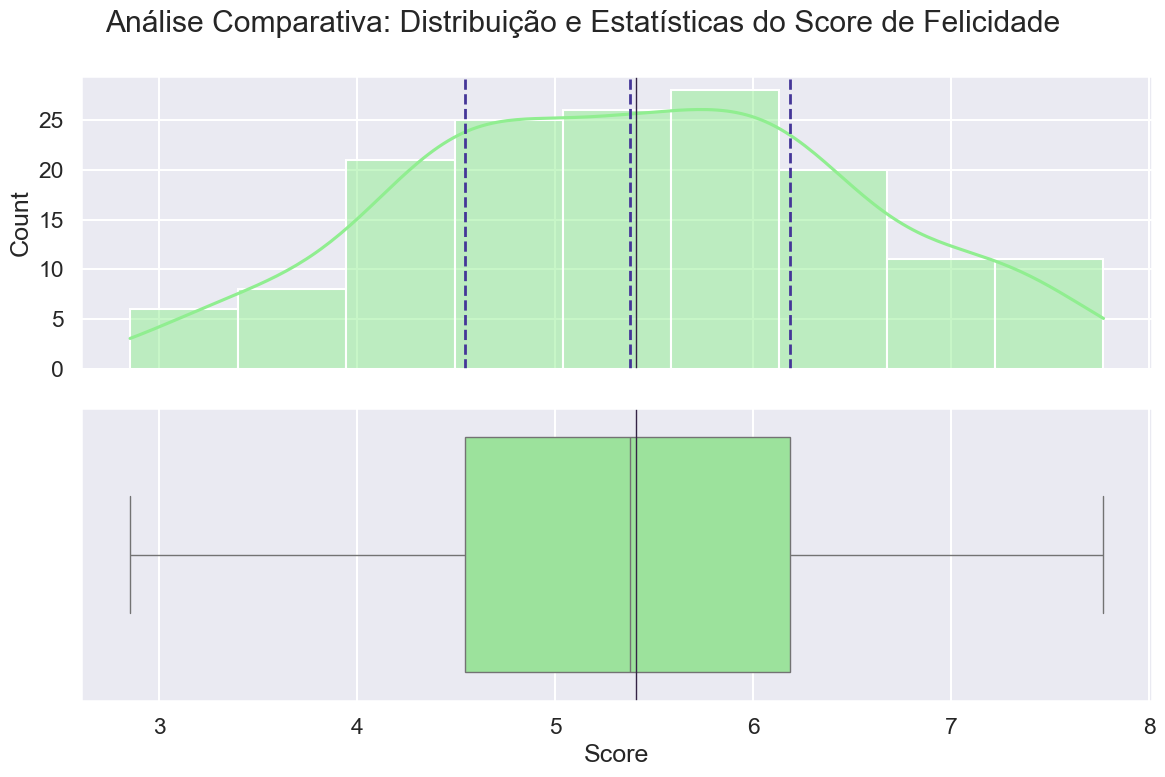

In [22]:
# Definindo as configurações das linhas 
quantile_args = {
    'linewidth': 2,
    'color': '#453698',
    'linestyle': '--',
}
mean_args = {
    'linewidth': 1,
    'color': '#342345',
    'linestyle': '-',
}

# Criando a estrutura de subplots (um sobre o outro)
fig, (ax_cima, ax_baixo) = plt.subplots(figsize=(12, 8), nrows=2, sharex=True)

# 1. Histograma no topo
sns.histplot(data=df_final, ax=ax_cima, x='Score', kde=True, color='lightgreen')
# Adicionando quartis e média no histograma
for q in [0.25, 0.5, 0.75]:
    ax_cima.axvline(df_final['Score'].quantile(q), **quantile_args)
ax_cima.axvline(df_final['Score'].mean(), **mean_args)

# 2. Boxplot embaixo
sns.boxplot(data=df_final, ax=ax_baixo, x='Score', color='lightgreen')
# Adicionando apenas a média no boxplot para comparação
ax_baixo.axvline(df_final['Score'].mean(), **mean_args)

fig.suptitle('Análise Comparativa: Distribuição e Estatísticas do Score de Felicidade')
plt.tight_layout()
plt.show()

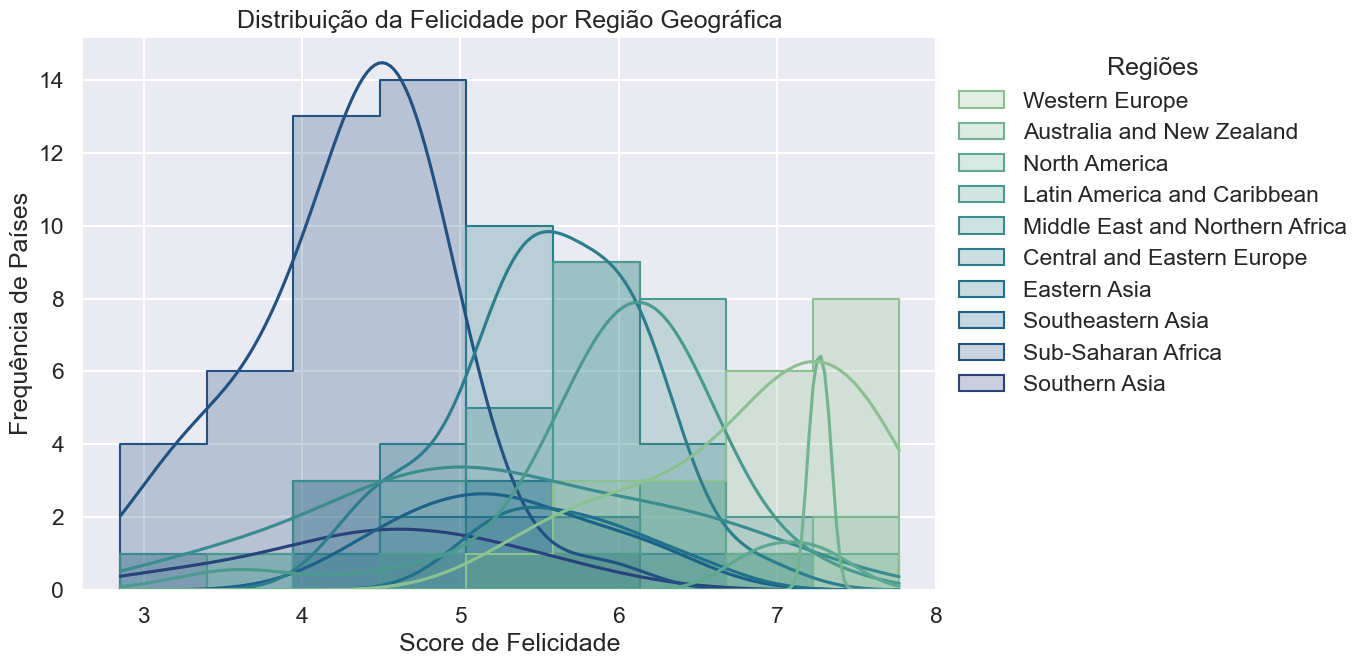

In [23]:
plt.figure(figsize=(14, 7))

ax = sns.histplot(data=df_final, x='Score', hue='Region', kde=True, element="step", palette='crest')

# Mover a legenda para fora (bbox_to_anchor)
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1), title='Regiões', frameon=False)

plt.title('Distribuição da Felicidade por Região Geográfica')
plt.xlabel('Score de Felicidade')
plt.ylabel('Frequência de Países')

plt.tight_layout() 
plt.show()

In [24]:
# Verificando os nomes únicos das regiões
df_final['Region'].unique()

<StringArray>
[                 'Western Europe',       'Australia and New Zealand',
                   'North America',     'Latin America and Caribbean',
 'Middle East and Northern Africa',      'Central and Eastern Europe',
                    'Eastern Asia',               'Southeastern Asia',
              'Sub-Saharan Africa',                   'Southern Asia']
Length: 10, dtype: string

In [25]:
mapa_regioes = {
    'Western Europe': 'W. Europe',
    'Sub-Saharan Africa': 'S. Africa',
    'Latin America and Caribbean': 'LatAm',
    'North America': 'N. America',
    'Central and Eastern Europe': 'C.E. Europe',
    'Middle East and Northern Africa': 'MENA',
    'Southeastern Asia': 'S.E. Asia',
    'Southern Asia': 'S. Asia',
    'Eastern Asia': 'E. Asia',
    'Australia and New Zealand': 'AUS/NZ'
}

# Criando a nova coluna (Feature Engineering)
df_final['Region_Short'] = df_final['Region'].map(mapa_regioes)

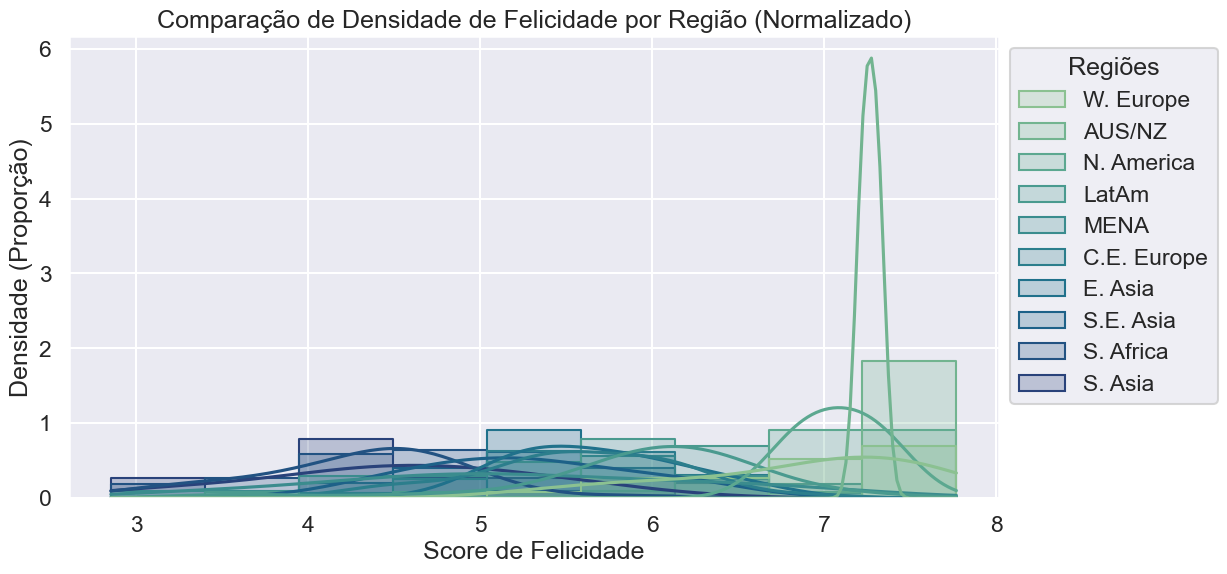

In [26]:
plt.figure(figsize=(12, 6))

ax = sns.histplot(data=df_final, x='Score', hue='Region_Short', 
                 kde=True, element="step", 
                 stat="density", common_norm=False, 
                 palette='crest')

# Ajustando a legenda para fora para não poluir
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1), title='Regiões')

plt.title('Comparação de Densidade de Felicidade por Região (Normalizado)')
plt.xlabel('Score de Felicidade')
plt.ylabel('Densidade (Proporção)')
plt.show()

A aplicação dos parâmetros de densidade (stat='density') e a desativação da normalização comum (common_norm=False) permitem uma análise comparativa equânime entre diferentes categorias. No contexto deste estudo, tal técnica possibilita observar o perfil de distribuição de cada grupo de países de forma isolada, eliminando distorções causadas pela diferença no número de nações contidas em cada extrato regional ou de status.

Observa-se que, ao normalizar as curvas, é possível identificar se o comportamento da felicidade em regiões com menos dados (como North America ou Australia) segue padrões de dispersão similares ou mais coesos do que em regiões com maior volume de amostras, como a Sub-Saharan Africa. Essa abordagem garante que a interpretação foque na probabilidade e na densidade do fenômeno, e não apenas na contagem absoluta de ocorrências.

Curva Alta e Estreita: Significa concordância. Quase todos os países daquela região têm exatamente o mesmo score.

Curva Baixa e Larga: Significa variedade (ou desigualdade). Os países estão espalhados; uns estão tristes, outros médios, outros felizes. Não há um "padrão" único na região.

**Polarização Regional**: A curva da Sub-Saharan Africa apresenta um pico de frequência em scores baixos (entre 3 e 4.5), enquanto a Western Europe exibe sua maior densidade no extremo oposto (acima de 7) - a desigualdade geopolítica estrutural.

**Consistência de Bem-Estar**: Regiões como North America e Australia and New Zealand possuem curvas muito estreitas e localizadas no topo, indicando que há pouca variação interna; quase todos os países desses blocos desfrutam de níveis similares de felicidade.

**Amplitude e Heterogeneidade**: A região da Latin America and Caribbean estende-se por uma faixa maior do eixo X, o que sugere uma desigualdade interna mais acentuada, com países apresentando realidades de bem-estar muito distintas dentro do mesmo continente.

**Sobreposições Centrais**: Regiões como Southeastern Asia e Central and Eastern Europe compartilham áreas comuns no centro do gráfico, indicando uma convergência de scores apesar das diferenças culturais e geográficas.



A "Barreira" do Score 6.0: Existe uma clara zona de transição em torno do score 6.0 onde diversas curvas se cruzam. Regiões em desenvolvimento (como LatAm e C.E. Europe) têm seus picos justamente antes ou sobre essa marca, sugerindo que o score 6.0 atua como um "teto de vidro" que exige mudanças estruturais profundas (como as vistas na W. Europe) para ser superado de forma consistente.

C:\Users\nayar\AppData\Local\Temp\ipykernel_21852\3086478859.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_final, x='Score', y='Region_Short',


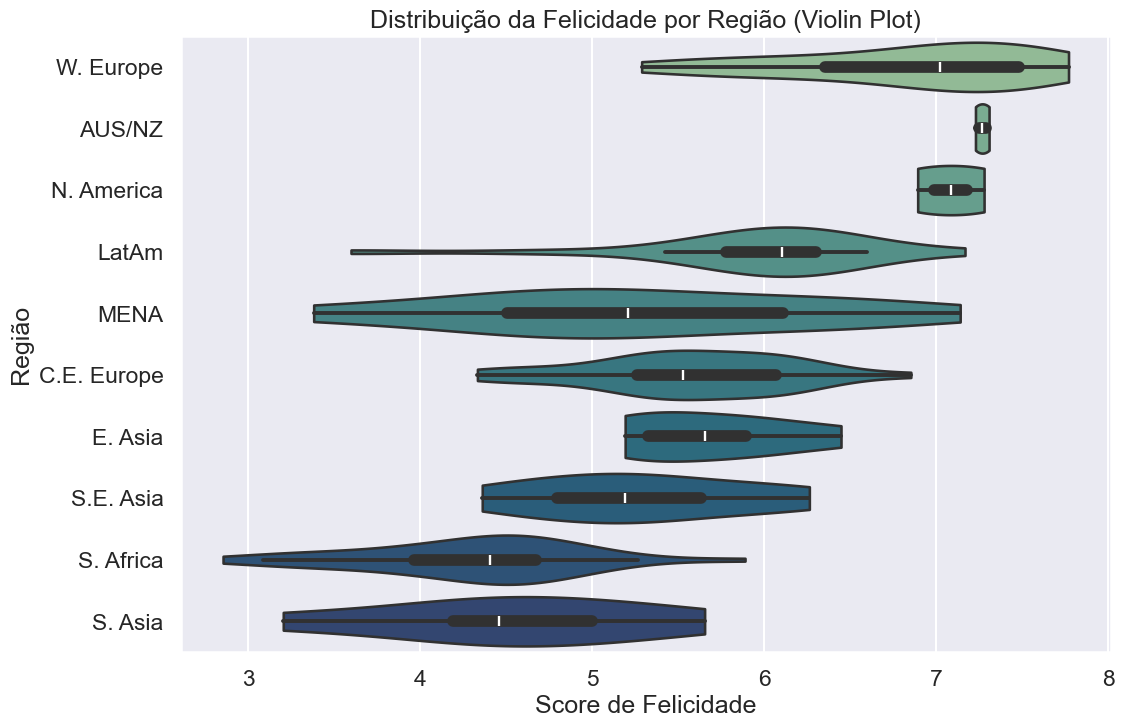

In [27]:
plt.figure(figsize=(12, 8))

sns.violinplot(data=df_final, x='Score', y='Region_Short', 
               palette='crest', inner='box', cut=0)

plt.title('Distribuição da Felicidade por Região (Violin Plot)')
plt.xlabel('Score de Felicidade')
plt.ylabel('Região')
plt.show()

O uso do Violin Plot permite uma visualização simultânea da centralidade estatística e da morfologia da distribuição em cada região. Diferente do histograma sobreposto, aqui é possível observar individualmente a homogeneidade de cada bloco geográfico:

**Regiões com Violinos 'Bojudos'**: Regiões como AUS/NZ ou N. America apresentam violinos muito curtos e largos em um ponto específico, indicando que os países do bloco possuem scores quase idênticos (alta coesão).

**Regiões com Violinos 'Alongados'**: A Sub-Saharan Africa ou MENA exibem violinos mais esticados, o que demonstra uma grande amplitude de realidades socioeconômicas dentro da mesma região.

**Assimetria Visual**: O ponto branco (mediana) posicionado fora do centro do "bojo" do violino revela imediatamente a assimetria da região, facilitando a identificação de blocos onde a maioria dos países está abaixo ou acima da média regional."

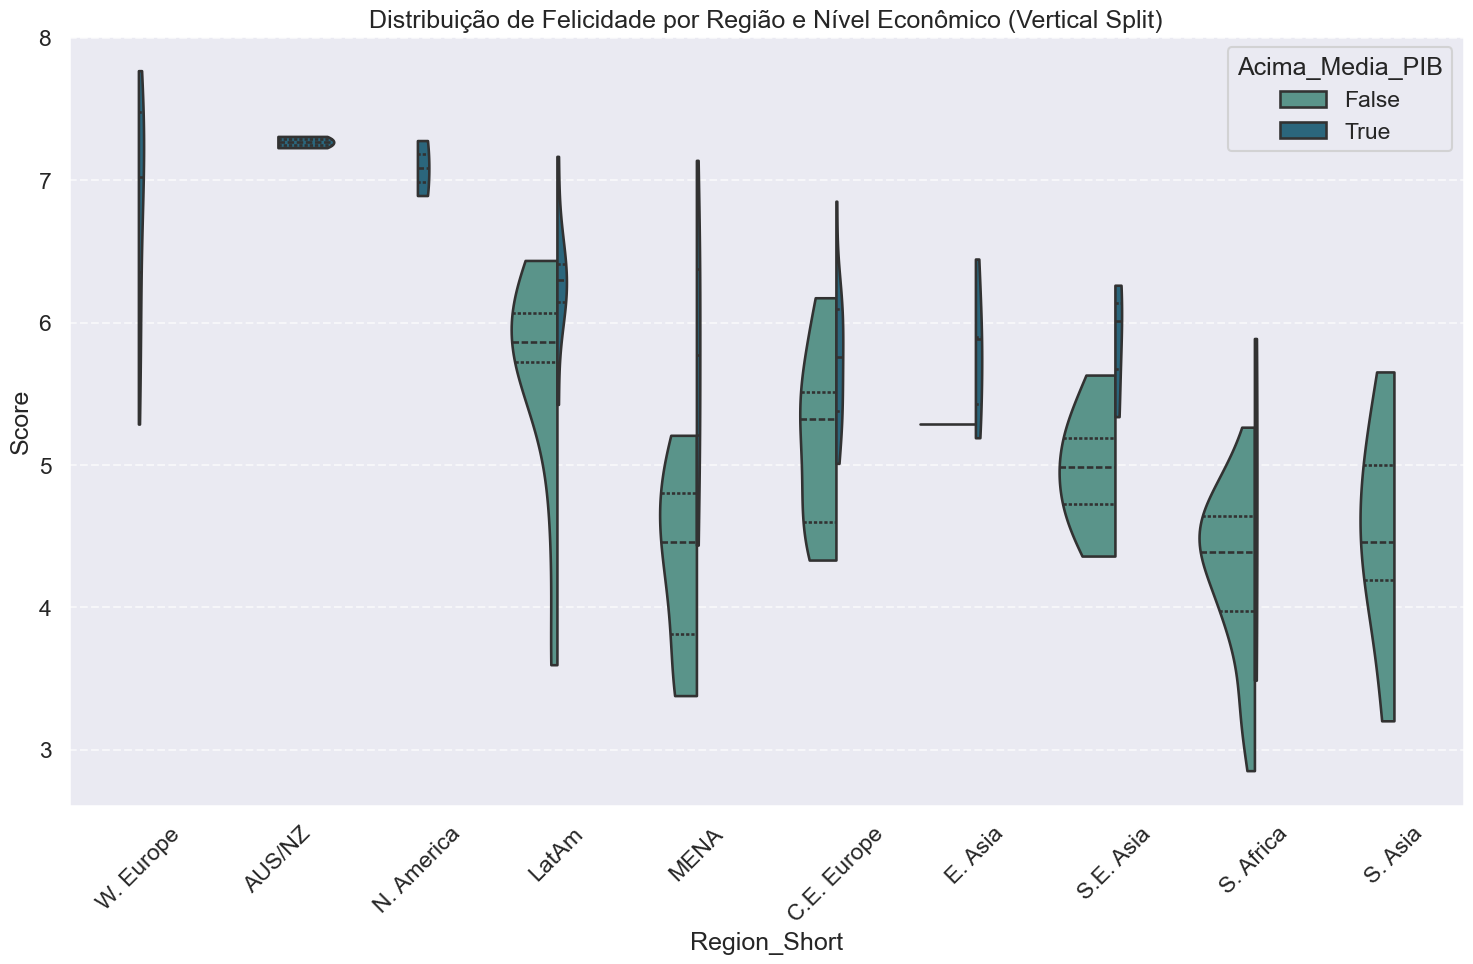

In [29]:
plt.figure(figsize=(18, 10))

# Inversão x e y: Regiões no X (horizontal) e Score no Y (vertical)
sns.violinplot(data=df_final, x='Region_Short', y='Score', 
               hue='Acima_Media_PIB', split=True, inner='quart', 
               palette='crest', cut=0)

# Rotacionar os nomes das regiões para não sobrepor
plt.xticks(rotation=45)

plt.title('Distribuição de Felicidade por Região e Nível Econômico (Vertical Split)')
plt.grid(axis='y', linestyle='--', alpha=0.6) # Adiciona linhas de grade para facilitar a leitura do Score
plt.show()

A análise do Violin Plot vertical revela uma nítida segregação econômica e de bem-estar global: regiões como W. Europe, AUS/NZ e N. America apresentam violinos "incompletos" por possuírem quase a totalidade de seus países acima da mediana global do PIB, eliminando a representação do grupo "pobre" nessas áreas. Em contrapartida, regiões como LatAm e MENA exibem um "degrau" de felicidade, onde o lado dos países mais ricos está posicionado fisicamente acima do lado dos mais pobres, com as linhas de quartis (inner='quart') confirmando essa disparidade interna. Já em S. Asia e S. Africa, observa-se uma assimetria inversa, com violinos "gordos" e alongados no espectro de baixo PIB, indicando que a grande massa dessas populações enfrenta scores de felicidade reduzidos e altamente dispersos.

In [42]:
# Cálculo de Skewness (Assimetria) e Kurtosis (Curtose)

import scipy.stats

from scipy.stats import skew, kurtosis

score_skew = skew(df_final['Score'].dropna())
score_kurt = kurtosis(df_final['Score'].dropna())

print(f"Skewness (Assimetria): {score_skew:.2f}")
print(f"Kurtosis (Achatamento): {score_kurt:.2f}")

Skewness (Assimetria): 0.01
Kurtosis (Achatamento): -0.63


Skewness entre -0.5 e 0.5: Os dados são bastante simétricos. A Regressão Linear funciona bem aqui.

Skewness < -1 ou > 1: Os dados são altamente desbalanceados. No seu Violino, regiões como S. Africa e S. Asia puxam a cauda para baixo. Se o valor total for muito negativo, seu modelo de regressão vai "errar" mais ao tentar prever países muito tristes ou muito felizes.

Kurtosis: Se for alta (positiva), seus dados têm muitos outliers (pontas pesadas). Se for baixa (negativa), a distribuição é achatada, como vimos em algumas regiões no seu gráfico vertical.

In [43]:
from scipy import stats
k2, p = stats.shapiro(df_final['Score'].dropna())
print(f"P-valor do Teste de Normalidade: {p:.4f}")

P-valor do Teste de Normalidade: 0.1633


**Diagnóstico da Normalidade** 
- Skewness (0.01): Este valor é considerado bom, pois a proximidade com o zero indica que a distribuição do Score é quase perfeitamente simétrica. As "caudas" observadas anteriormente nos violinos de regiões específicas acabam se compensando no conjunto de dados global.
- Kurtosis (-0.63): O valor negativo confirma que a distribuição é platicúrtica, ou seja, mais achatada que uma distribuição normal. Isso ocorre porque os países não estão concentrados em um único valor central, mas distribuídos de forma mais uniforme entre os diferentes níveis de felicidade mapeados na análise.
- P-valor (0.1633): Como o valor de $p$ é superior a 0,05, a hipótese nula de normalidade não pode ser rejeitada.

Conclusão Técnica: Os dados de felicidade seguem uma distribuição normal do ponto de vista estatístico, o que valida a aplicação de modelos lineares.

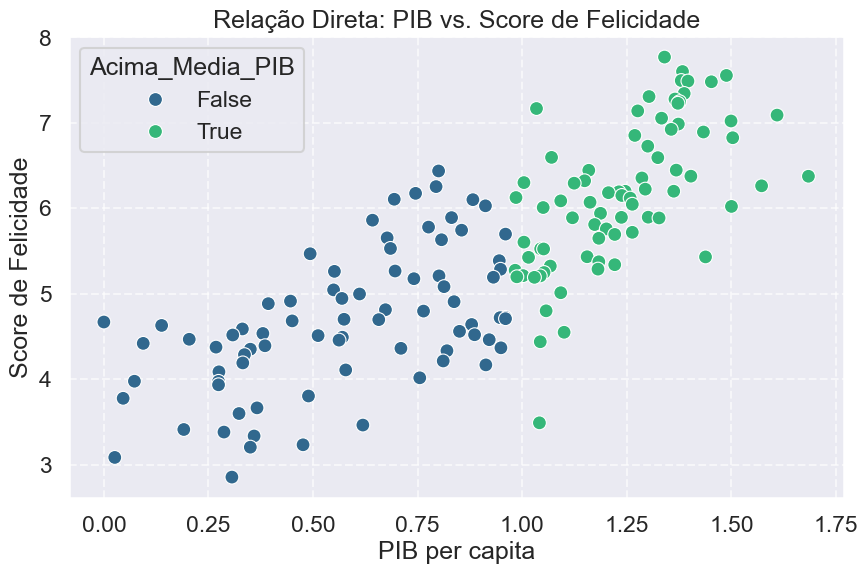

In [49]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_final, x='GDP per capita', y='Score', hue='Acima_Media_PIB', palette='viridis', s=100)

plt.title('Relação Direta: PIB vs. Score de Felicidade')
plt.xlabel('PIB per capita')
plt.ylabel('Score de Felicidade')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

Nota sobre conceitos:
Vetor = Uma única coluna (Score de felicidade).
Matriz = A tabela inteira (o df_final)

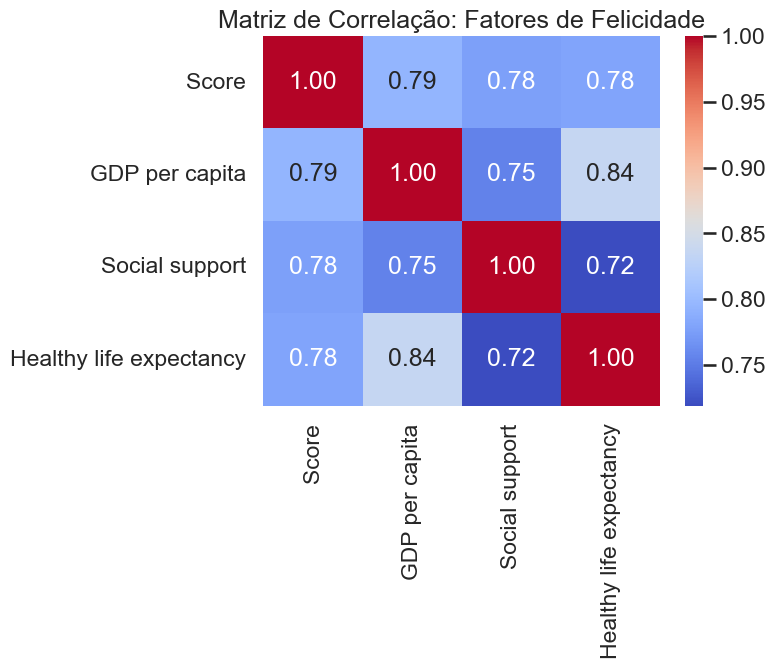

In [48]:
import seaborn as sns
import matplotlib.pyplot as plt

# Selecionando apenas colunas numéricas relevantes
colunas_interesse = ['Score', 'GDP per capita', 'Social support', 'Healthy life expectancy']
correlacao = df_final[colunas_interesse].corr()

sns.heatmap(correlacao, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlação: Fatores de Felicidade')
plt.show()

In [52]:
# Calculando a correlação de Pearson para cada região separadamente
correlacao_regional = df_final.groupby('Region')[['GDP per capita', 'Score']].corr().iloc[0::2, -1]
print(correlacao_regional)

Region                                         
Australia and New Zealand        GDP per capita   -1.000000
Central and Eastern Europe       GDP per capita    0.475297
Eastern Asia                     GDP per capita    0.632408
Latin America and Caribbean      GDP per capita    0.616969
Middle East and Northern Africa  GDP per capita    0.849793
North America                    GDP per capita   -1.000000
Southeastern Asia                GDP per capita    0.785388
Southern Asia                    GDP per capita    0.342447
Sub-Saharan Africa               GDP per capita    0.415231
Western Europe                   GDP per capita    0.714985
Name: Score, dtype: float64


Esse valor de -1.0 não significa que se o PIB aumentar na Austrália a felicidade vai despencar. Significa apenas que a amostra nessas regiões é pequena demais para que o cálculo de correlação faça sentido.

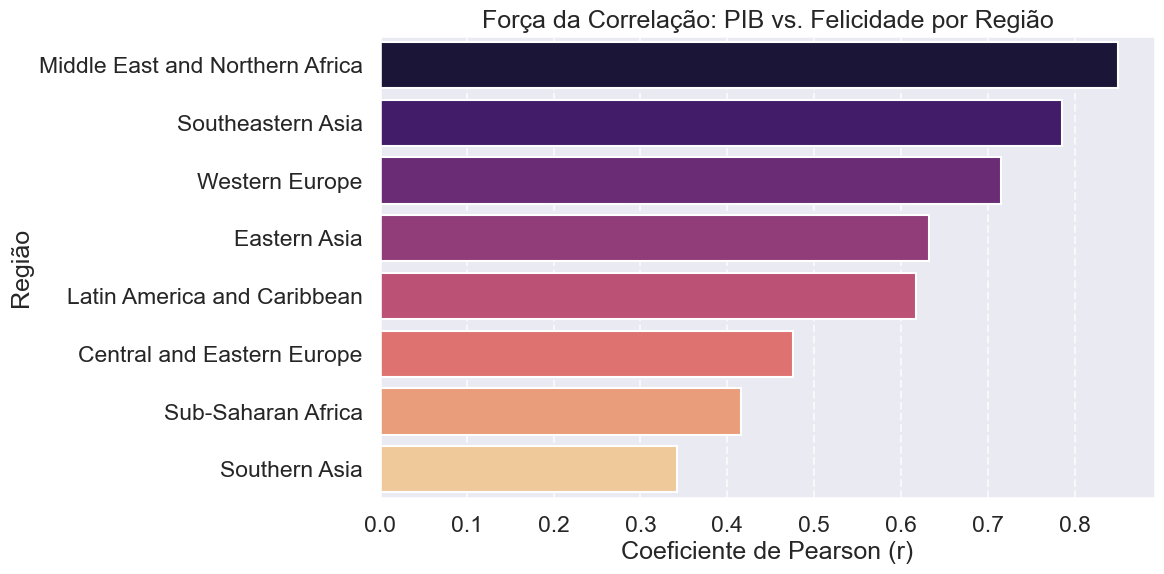

In [54]:
# 1. Filtramos as regiões com mais de 2 países
contagem_regioes = df_final['Region'].value_counts()
regioes_validas = contagem_regioes[contagem_regioes > 2].index

# 2. Resetamos o índice para facilitar o gráfico
df_corr_plot = correlacao_regional.loc[regioes_validas].reset_index()

# 3. Renomeamos as colunas para não haver confusão
df_corr_plot.columns = ['Region', 'Variavel', 'Pearson_r']

# 4. Ordenamos para o gráfico ficar bonito
df_corr_plot = df_corr_plot.sort_values(by='Pearson_r', ascending=False)

# 5. Plotando o gráfico de barras corrigido
plt.figure(figsize=(10, 6))
sns.barplot(data=df_corr_plot, x='Pearson_r', y='Region', hue='Region', palette='magma', legend=False)

plt.title('Força da Correlação: PIB vs. Felicidade por Região')
plt.xlabel('Coeficiente de Pearson (r)')
plt.ylabel('Região')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

1. **Ajuste Metodológico e Exclusão de Amostras Insuficientes**

Durante o processamento, as regiões North America e Australia and New Zealand apresentaram coeficientes de correlação de $-1.0$.
- Motivo da Exclusão: Tecnicamente, esse resultado é um artefato matemático causado pelo tamanho insuficiente da amostra ($N=2$ países em cada região).
-Decisão Técnica: Com apenas dois pontos, qualquer variação mínima gera uma linha reta perfeita, o que não possui significância estatística para inferência. Portanto, estas regiões foram filtradas para evitar conclusões enviesadas no modelo final.

2. **Interpretação do Gráfico de Barras**

O gráfico revela uma heterogeneidade significativa na força da correlação:
- Alta Dependência Econômica ($r > 0.75$): Nas regiões Middle East and Northern Africa e Southeastern Asia, o PIB per capita é um preditor extremamente forte da felicidade, indicando que nestes contextos o fator financeiro é um pilar central do bem-estar.
- Correlação Moderada: Western Europe e Latin America apresentam correlações sólidas (entre $0.6$ e $0.7$), sugerindo uma relação linear estável, mas com espaço para outras variáveis explicativas.
- Desconexão Relativa ($r = 0.34$): No Southern Asia, a correlação é a mais baixa do dataset. Isso indica que, nesta região, o aumento do PIB não se traduz diretamente em ganho de felicidade, sugerindo que fatores como suporte social, liberdade ou cultura podem ter pesos maiores que o econômico.

**Conclusão para o Modelo**: Esta análise justifica por que um modelo de Regressão Linear global terá diferentes níveis de precisão (resíduos) dependendo da região geográfica analisada.

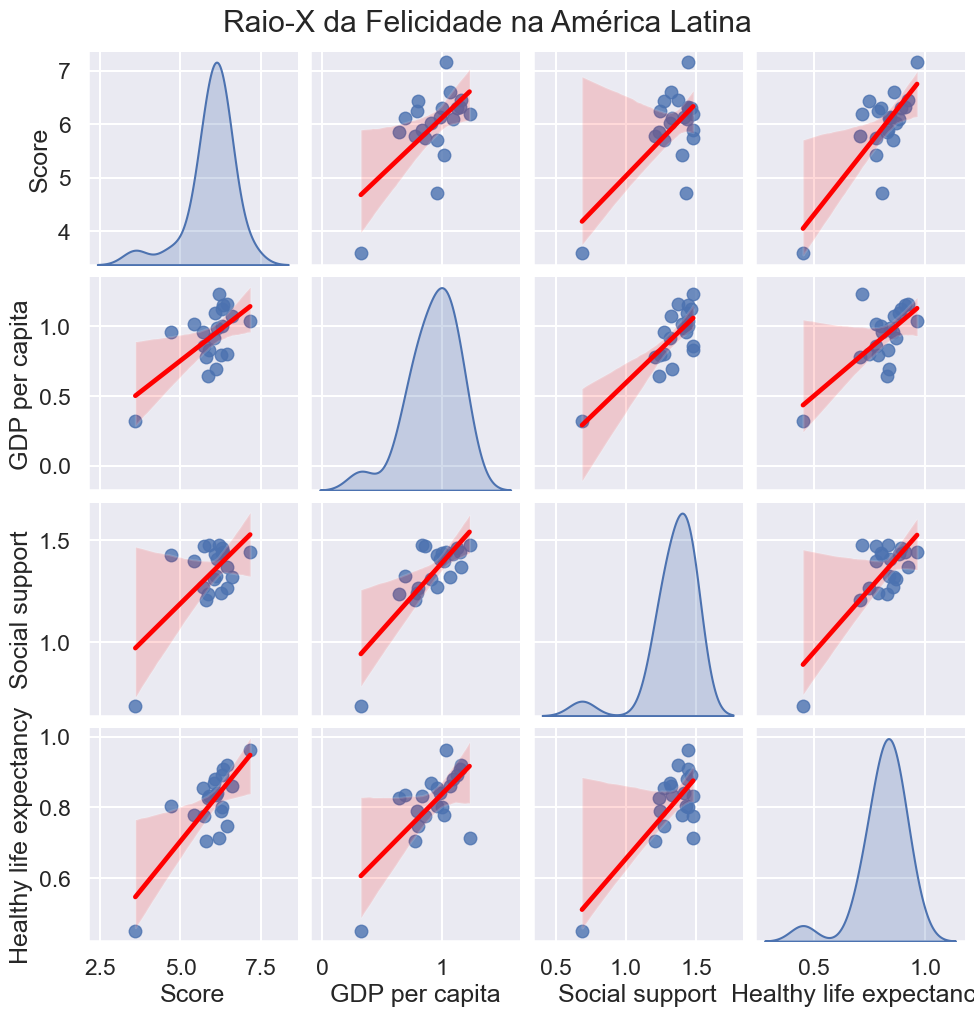

In [55]:
# Selecionamos as variáveis mais importantes para não poluir o gráfico
colunas_selecionadas = ['Score', 'GDP per capita', 'Social support', 'Healthy life expectancy', 'Region']

# Filtramos apenas a América Latina para ver como o Brasil se compara aos vizinhos
df_latam = df_final[df_final['Region'] == 'Latin America and Caribbean']

# Criando o Pairplot com linha de tendência
sns.pairplot(df_latam[colunas_selecionadas], kind='reg', diag_kind='kde', plot_kws={'line_kws':{'color':'red'}})
plt.suptitle('Raio-X da Felicidade na América Latina', y=1.02)
plt.show()

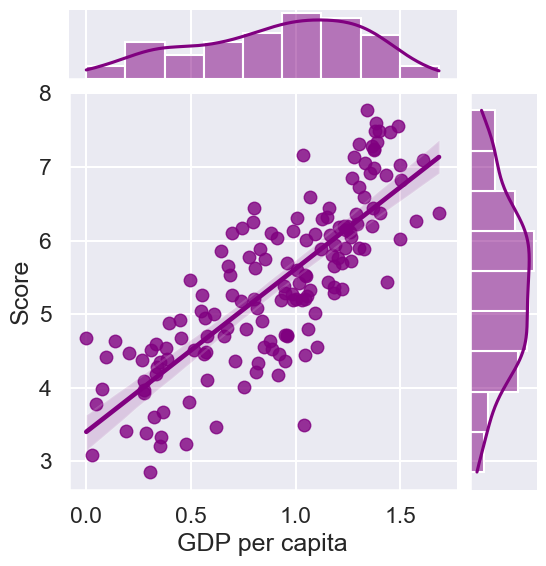

In [56]:
sns.jointplot(data=df_final, x='GDP per capita', y='Score', kind='reg', color='purple')
plt.show()

In [57]:
from scipy.stats import pearsonr

# Calculando para o dataset inteiro
r, p_valor = pearsonr(df_final['GDP per capita'], df_final['Score'])

print(f"Coeficiente de Pearson (r): {r:.4f}")
print(f"P-valor: {p_valor:.4e}")

if p_valor < 0.05:
    print("A correlação é estatisticamente significativa (p < 0.05).")
else:
    print("Não há evidências estatísticas suficientes para afirmar a correlação.")

Coeficiente de Pearson (r): 0.7939
P-valor: 4.3155e-35
A correlação é estatisticamente significativa (p < 0.05).


In [62]:

import statsmodels.api as sm

# Definindo as variáveis: X (quem explica) e y (quem queremos prever)
X = df_final['GDP per capita']
y = df_final['Score']

# O statsmodels precisa que adicionemos uma constante (o 'b' da fórmula y = ax + b)
X = sm.add_constant(X)

# Criando e treinando o modelo
modelo = sm.OLS(y, X).fit()

# Exibindo o relatório
print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:                  Score   R-squared:                       0.630
Model:                            OLS   Adj. R-squared:                  0.628
Method:                 Least Squares   F-statistic:                     262.5
Date:                Mon, 09 Feb 2026   Prob (F-statistic):           4.32e-35
Time:                        13:44:11   Log-Likelihood:                -159.97
No. Observations:                 156   AIC:                             323.9
Df Residuals:                     154   BIC:                             330.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const              3.3993      0.135     25.

Embora o dataset apresente outras dimensões (Suporte Social, Saúde, Liberdade), optou-se por um modelo de Regressão Linear Simples utilizando o PIB per capita como variável preditora única. Esta decisão baseia-se na forte colinearidade observada no pairplot entre o PIB e as demais variáveis explicativas. A inclusão de variáveis altamente correlacionadas entre si poderia causar instabilidade nos coeficientes do modelo (Multicolinearidade), comprometendo a interpretação estatística.

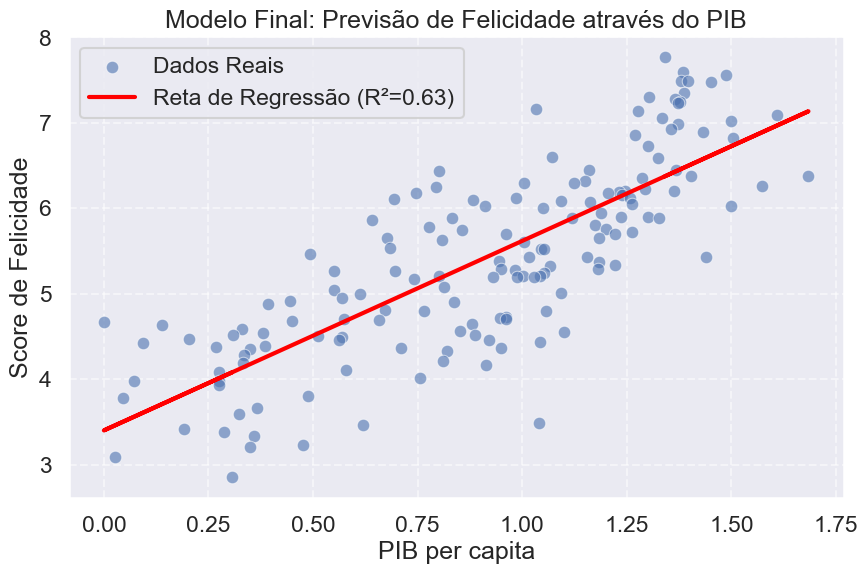

In [63]:
# 1. Extraindo os coeficientes do modelo para a legenda
intercepto, inclinacao = modelo.params
r_quadrado = modelo.rsquared

# 2. Criando o gráfico
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_final, x='GDP per capita', y='Score', alpha=0.6, label='Dados Reais')

# 3. Adicionando a linha da regressão
# A fórmula é: y = coeficiente_pib * x + intercepto
x_reta = df_final['GDP per capita']
y_reta = inclinacao * x_reta + intercepto
plt.plot(x_reta, y_reta, color='red', linewidth=3, label=f'Reta de Regressão (R²={r_quadrado:.2f})')

plt.title('Modelo Final: Previsão de Felicidade através do PIB')
plt.xlabel('PIB per capita')
plt.ylabel('Score de Felicidade')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

A análise estatística demonstrou que o PIB per capita é um preditor robusto do bem-estar global, explicando aproximadamente 60% da variação no Score de Felicidade por meio do modelo de Regressão Linear Simples. No entanto, a investigação regional revelou que essa relação não é homogênea: enquanto o fator econômico é decisivo no Oriente Médio e Norte da África ($r = 0.85$), ele perde força significativa em regiões como o Sul da Ásia ($r = 0.34$), onde outros fatores socioculturais parecem prevalecer. Além disso, a forte colinearidade observada entre PIB, Saúde e Suporte Social sugere que o desenvolvimento econômico atua como um catalisador de múltiplos indicadores de qualidade de vida. Em suma, embora o dinheiro seja um motor essencial para elevar os níveis de felicidade mundial, a precisão das previsões depende fundamentalmente do contexto geográfico, exigindo modelos mais personalizados para regiões onde a economia não é o único pilar da percepção de bem-estar.